# Synthetic mineral processing plant

Generate 8,000 sequential observations of five slowly varying disturbances, five smoothly adjusted operator controls, and two lagged, noisy outputs. The steady-state response uses only smooth, differentiable functions. Run this notebook from its `notebooks/` directory; the CSV is written to `../data/`.

### Reading the columns

The five `d*` columns are measured disturbances, the five `u*` columns are operator setpoints in physical units, and `y1_quality` / `y2_energy_load` are measurements. CSV row order represents time; there is no explicit timestamp. These synthetic values are not calibrated plant data.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.special import expit

sns.set_theme(style="whitegrid")
DISTURBANCES = ["d1_feed_grade", "d2_hardness", "d3_moisture", "d4_impurity", "d5_ambient"]
CONTROLS = ["u1_feed_rate", "u2_water_rate", "u3_reagent_rate", "u4_speed", "u5_temperature_setpoint"]
OUTPUTS = ["y1_quality", "y2_energy_load"]

The latent disturbances follow a stationary, correlated AR(1) process. Smooth saturating transforms keep the physical variables in plausible ranges without clipping. Operator targets respond to feed conditions and slowly evolving operator bias; the actual controls approach those targets gradually. Quality and energy are smooth functions of all ten inputs, followed by first-order output dynamics and measurement noise.

## Building the process from latent conditions

Disturbances follow a correlated autoregressive process: `z[t] = 0.985 z[t-1] + innovation[t]`. Shared shocks create cross-variable correlations and `tanh` maps latent values to plausible physical ranges without hard clipping. Their high persistence means neighboring samples are not independent.

Operator targets depend on feed conditions plus a slowly changing operator bias. Actual controls approach targets by 5% per step, mimicking gradual manual adjustments. The *static* plant map uses sigmoid, `tanh`, Gaussian-shaped water matching, quadratic penalties, interactions and `logaddexp`. `steady_state_response(d, u)` takes two arrays of five columns and returns quality and energy; later notebooks reuse exactly this equation as ground truth.

Both static outputs drive first-order dynamics: `state[t] = state[t-1] + (1 - exp(-1/tau)) * (target[t] - state[t-1])`. The quality and energy time constants are 8 and 15 samples. Gaussian sensor noise is applied *after* this lag. A measured row therefore need not equal its instantaneous static response.

In [2]:
def steady_state_response(d, u):
    """Differentiable static plant map; d and u have five columns each."""
    grade = (d[:, 0] - 1.5) / 0.35
    hardness = (d[:, 1] - 65.0) / 12.0
    moisture = (d[:, 2] - 8.0) / 3.0
    impurity = (d[:, 3] - 2.0) / 0.8
    ambient = (d[:, 4] - 25.0) / 8.0
    feed = (u[:, 0] - 115.0) / 12.0
    water = (u[:, 1] - 90.0) / 12.0
    reagent = (u[:, 2] - 3.8) / 0.65
    speed = (u[:, 3] - 80.0) / 6.0
    temperature = (u[:, 4] - 65.0) / 5.0

    recovery = expit(0.85 * grade - 0.45 * hardness - 0.65 * impurity
                     + 0.65 * reagent + 0.30 * speed + 0.30 * reagent * impurity)
    water_match = np.exp(-0.5 * ((water - 0.35 * feed + 0.25 * moisture) / 0.65) ** 2)
    quality = (78.0 + 12.0 * recovery + 4.0 * water_match
               + 1.6 * np.tanh(temperature - 0.4 * ambient)
               - 1.5 * (feed - 0.35 * speed) ** 2
               - 0.8 * (reagent - 0.4 * impurity) ** 2)

    energy = (65.0 + 9.0 * np.logaddexp(0.0, 0.5 * feed + 0.5 * hardness
                                        + 0.3 * speed + 0.2 * moisture)
              + 4.0 * (speed + 0.2 * hardness) ** 2
              + 2.0 * (temperature - 0.2 * ambient) ** 2
              + 1.5 * feed * hardness + 0.8 * water * feed)
    return np.column_stack((quality, energy))


def generate_process_data(n_samples=8000, seed=42):
    """Return reproducible, time-ordered noisy process measurements."""
    rng = np.random.default_rng(seed)
    phi = 0.985
    disturbance_scale = 0.13
    loadings = np.array([[0.65, 0.10], [-0.45, 0.50], [0.25, 0.55],
                         [-0.40, 0.30], [0.10, -0.20]])
    innovation_cov = disturbance_scale ** 2 * (loadings @ loadings.T + 0.64 * np.eye(5))
    latent = np.empty((n_samples, 5))
    latent[0] = rng.multivariate_normal(np.zeros(5), innovation_cov / (1.0 - phi ** 2))
    shocks = rng.multivariate_normal(np.zeros(5), innovation_cov, size=n_samples)
    for t in range(1, n_samples):
        latent[t] = phi * latent[t - 1] + shocks[t]
    centers = np.array([1.5, 65.0, 8.0, 2.0, 25.0])
    spans = np.array([0.35, 12.0, 3.0, 0.8, 8.0])
    d = centers + spans * np.tanh(latent)
    normalized_d = (d - centers) / spans
    grade, hardness, moisture, impurity, ambient = normalized_d.T

    operator_bias = np.empty((n_samples, 5))
    operator_bias[0] = rng.normal(0.0, 0.3, size=5)
    for t in range(1, n_samples):
        operator_bias[t] = 0.97 * operator_bias[t - 1] + rng.normal(0.0, 0.07, size=5)
    targets = np.column_stack((
        0.70 * grade - 0.50 * hardness - 0.50 * moisture,
        0.50 * hardness - 0.45 * moisture + 0.35 * grade,
        0.65 * impurity - 0.35 * grade + 0.30 * hardness,
        0.45 * hardness + 0.30 * grade,
        -0.40 * ambient + 0.25 * moisture,
    )) + operator_bias
    control_state = np.empty((n_samples, 5))
    control_state[0] = np.tanh(targets[0])
    for t in range(1, n_samples):
        control_state[t] = 0.95 * control_state[t - 1] + 0.05 * np.tanh(targets[t])
    u = np.array([115.0, 90.0, 3.8, 80.0, 65.0]) + np.array([12.0, 12.0, 0.65, 6.0, 5.0]) * control_state

    static_outputs = steady_state_response(d, u)
    process_outputs = np.empty_like(static_outputs)
    process_outputs[0] = static_outputs[0]
    alpha = 1.0 - np.exp(-1.0 / np.array([8.0, 15.0]))
    for t in range(1, n_samples):
        process_outputs[t] = process_outputs[t - 1] + alpha * (static_outputs[t] - process_outputs[t - 1])
    measured_outputs = process_outputs + rng.normal(0.0, [0.25, 0.35], size=(n_samples, 2))
    return pd.DataFrame(np.column_stack((d, u, measured_outputs)),
                        columns=DISTURBANCES + CONTROLS + OUTPUTS)


## Reproduce and export the dataset

A local generator with seed `42` makes the same 8,000-row trajectory on repeated runs. The assertions check the exact `8,000 x 12` shape, missing values and reproducibility before writing `data/synthetic_process_data.csv` with no index. Keep the rows in order for the chronological split in notebook 02.

In [3]:
data = generate_process_data(n_samples=8000, seed=42)
assert data.shape == (8000, 12)
assert data.notna().all().all()
assert data.equals(generate_process_data(n_samples=8000, seed=42))
output_path = Path("../data/synthetic_process_data.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)
data.to_csv(output_path, index=False)
print(f"Saved {data.shape[0]:,} observations to {output_path.resolve()}")
display(data.head())

Saved 8,000 observations to C:\Users\jaco238653\OneDrive - Hatch LTD\Documents\Python\NN_Optimization\neural-network-inverse-optimization\data\synthetic_process_data.csv


,d1_feed_grade,d2_hardness,d3_moisture,d4_impurity,d5_ambient,u1_feed_rate,u2_water_rate,u3_reagent_rate,u4_speed,u5_temperature_setpoint,y1_quality,y2_energy_load
0,1.354887,70.163446,10.649221,1.594952,27.462751,104.547194,87.052000,3.750329,79.694070,66.361444,85.878194,70.448477
1,1.327805,71.155435,10.565955,1.652721,28.135442,104.525841,87.042341,3.754733,79.685749,66.355819,86.526586,71.218384
2,1.340741,69.679504,10.529662,1.661333,28.943291,104.508576,86.977952,3.753472,79.624532,66.330733,85.737312,70.251532
3,1.354333,70.244548,10.580603,1.587439,28.682306,104.497195,86.928546,3.753079,79.570422,66.273350,85.837796,70.692870
4,1.361147,70.069385,10.485302,1.565840,29.007382,104.496227,86.849946,3.752088,79.478167,66.207935,85.962601,70.120301


## Time series, output distributions, and correlations

### Trace every measured variable through time

The twelve time-series panels reveal persistent disturbances, smooth operator actions and lagged, noisy responses. Visual smoothness does not by itself establish that the variables are suitable for causal control.

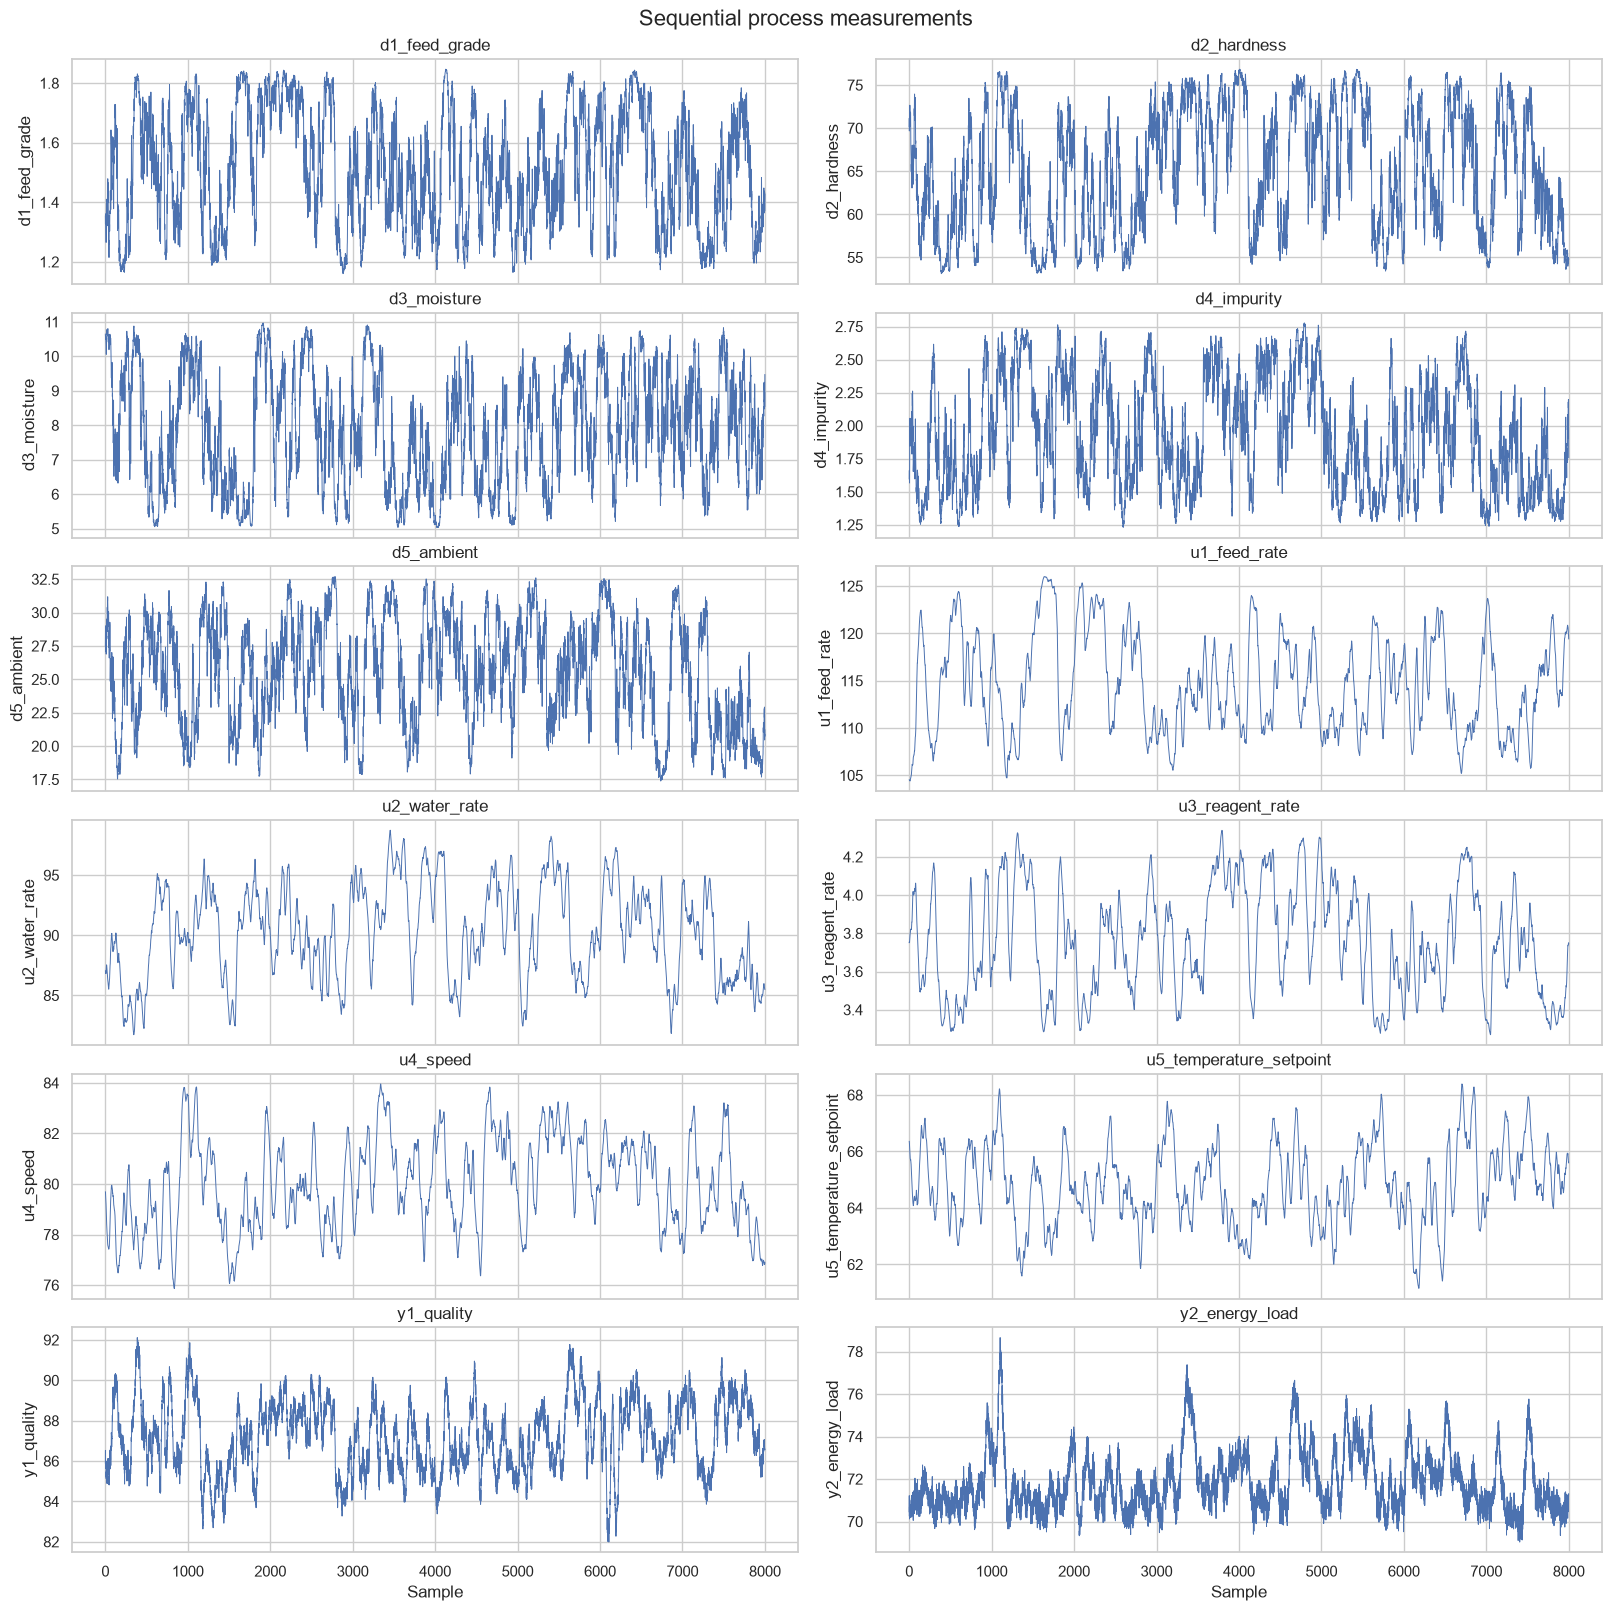

In [4]:
fig, axes = plt.subplots(6, 2, figsize=(16, 16), sharex=True, constrained_layout=True)
for ax, column in zip(axes.flat, data.columns):
    ax.plot(data.index, data[column], linewidth=0.7)
    ax.set_title(column)
    ax.set_ylabel(column)
for ax in axes[-1]:
    ax.set_xlabel("Sample")
fig.suptitle("Sequential process measurements", fontsize=16)
plt.show()

### Inspect marginal output distributions

The histograms and kernel-density overlays show the observed ranges, skew and tails of measured quality and energy. They include both plant dynamics and sensor noise; they cannot establish what caused an output change.

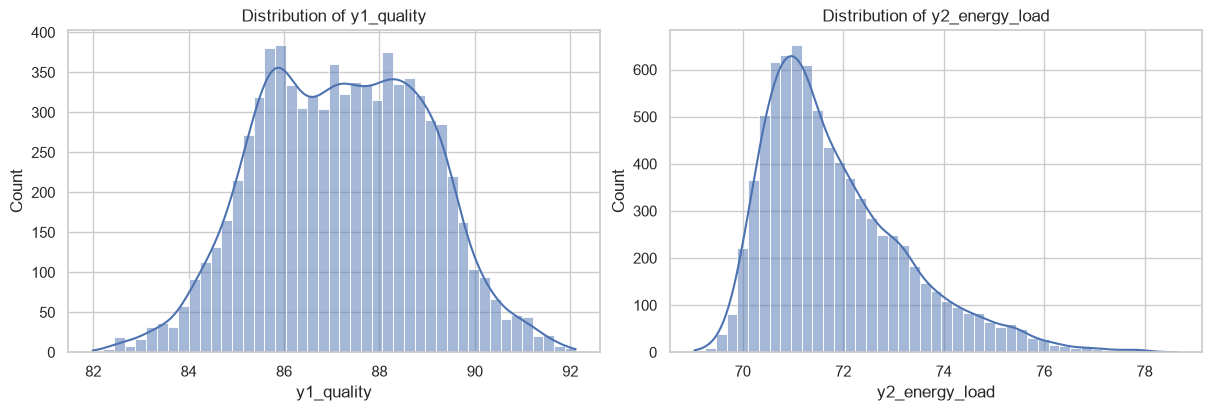

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for ax, column in zip(axes, OUTPUTS):
    sns.histplot(data[column], bins=45, kde=True, ax=ax)
    ax.set_title(f"Distribution of {column}")
plt.show()

### Read correlations cautiously

Pearson correlation summarizes linear association over the whole sequence. Operator actions respond to disturbances and outputs lag both, so correlation is neither a causal plant gain nor the local nonlinear derivative used later for inverse optimization.

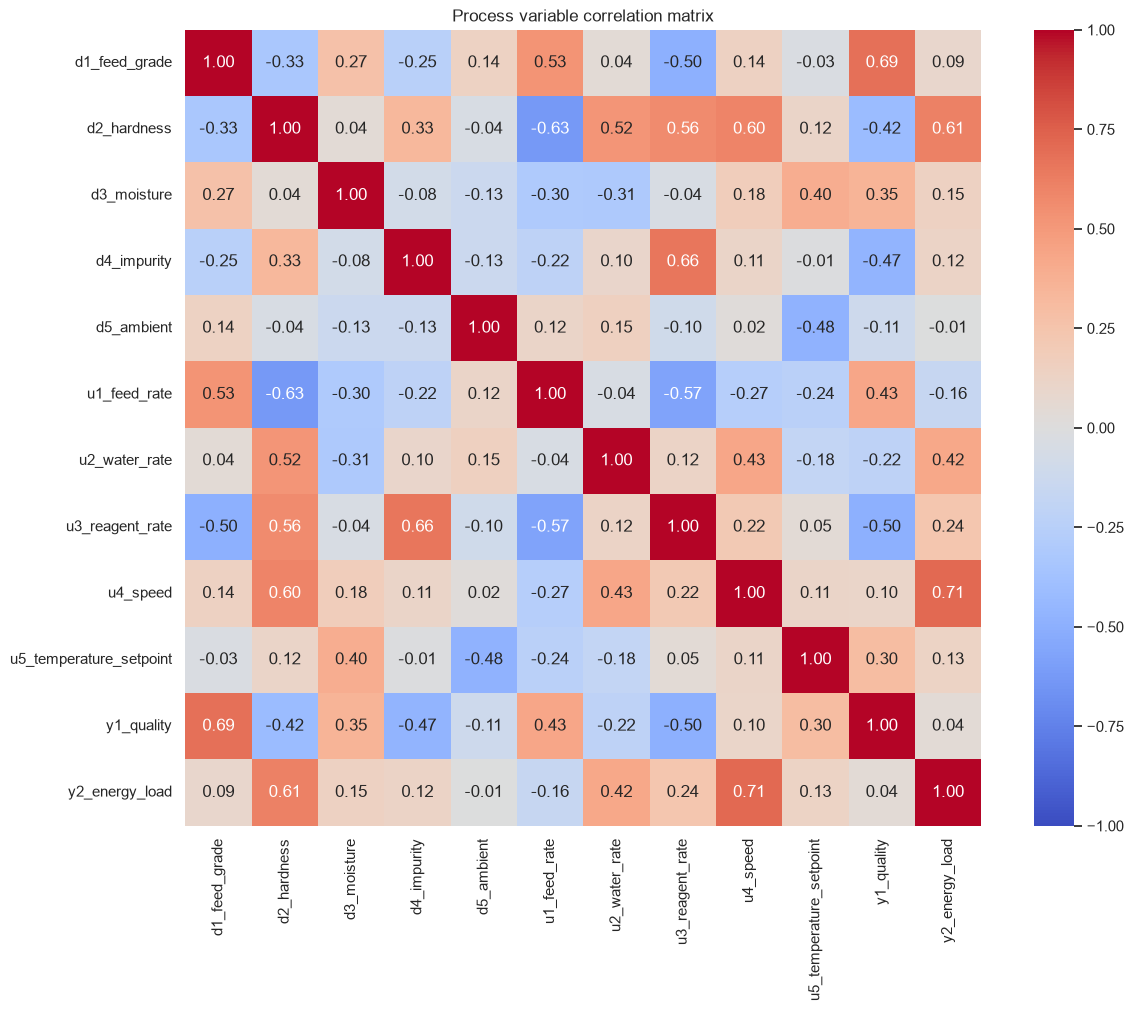

In [6]:
fig, ax = plt.subplots(figsize=(12, 10), constrained_layout=True)
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Process variable correlation matrix")
plt.show()